In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import os

# Load the datasets (update paths if your files are in a specific folder)
# 1. Load Data (Using a sample for EDA efficiency)
BASE_DIR = '/Users/abannee/Documents/GitHub/fraud_detection_ml/'
DATA_DIR = os.path.join(BASE_DIR, 'data/raw')
train_transaction = pd.read_csv(os.path.join(DATA_DIR, 'train_transaction.csv'))
train_identity = pd.read_csv(os.path.join(DATA_DIR, 'train_transaction.csv'))

# Merge on TransactionID
df = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
print(f"Dataset loaded successfully. Shape: {df.shape}")

Dataset loaded successfully. Shape: (590540, 787)


In [11]:
df.head()

,TransactionID,isFraud_x,TransactionDT_x,TransactionAmt_x,ProductCD_x,card1_x,card2_x,card3_x,card4_x,card5_x,...,V330_y,V331_y,V332_y,V333_y,V334_y,V335_y,V336_y,V337_y,V338_y,V339_y
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


/var/folders/2w/c8v4yt5j21s3nkv8j9x_fc340000gn/T/ipykernel_59695/853253198.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='isFraud_x', data=df, palette='viridis')


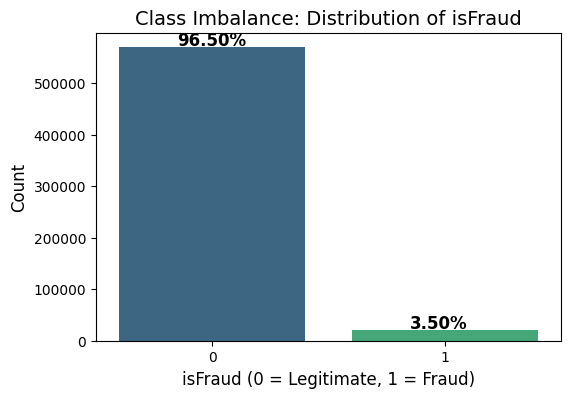

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(x='isFraud_x', data=df, palette='viridis')

# Add percentages on top of bars
total = len(df)
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x = p.get_x() + p.get_width() / 2 - 0.15
    y = p.get_y() + p.get_height() + (total * 0.005)
    plt.gca().annotate(percentage, (x, y), fontsize=12, fontweight='bold')

plt.title('Class Imbalance: Distribution of isFraud', fontsize=14)
plt.xlabel('isFraud (0 = Legitimate, 1 = Fraud)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

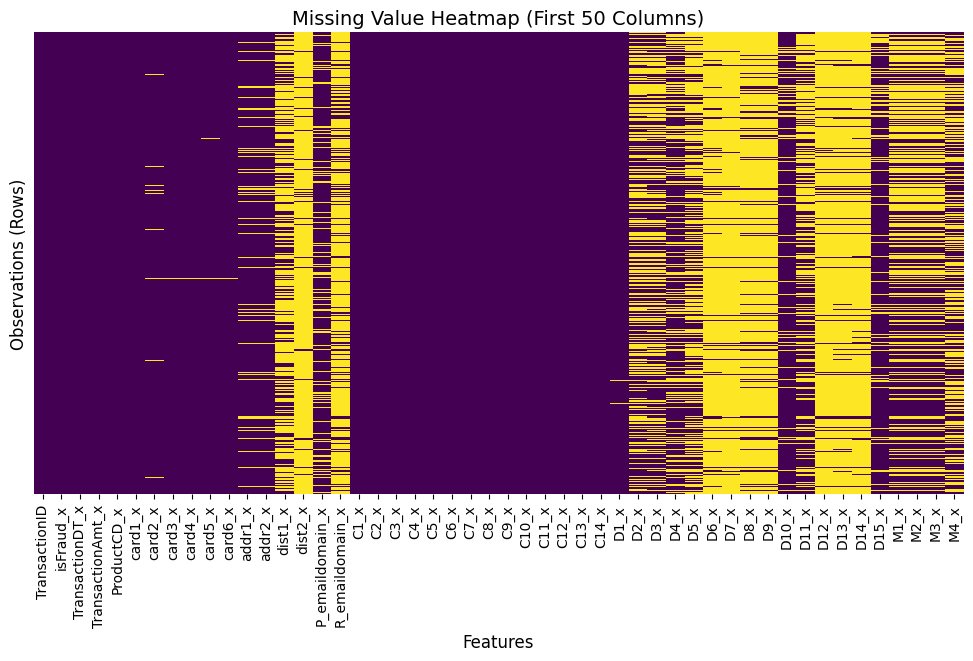

In [5]:
# Calculate percentage of missing values per column
missing_pct = df.isnull().mean() * 100

# Select a representative subset of columns (e.g., first 50 columns) to make the heatmap readable
sample_cols = df.columns[:50]

plt.figure(figsize=(12, 6))
sns.heatmap(df[sample_cols].isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap (First 50 Columns)', fontsize=14)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Observations (Rows)', fontsize=12)
plt.show()

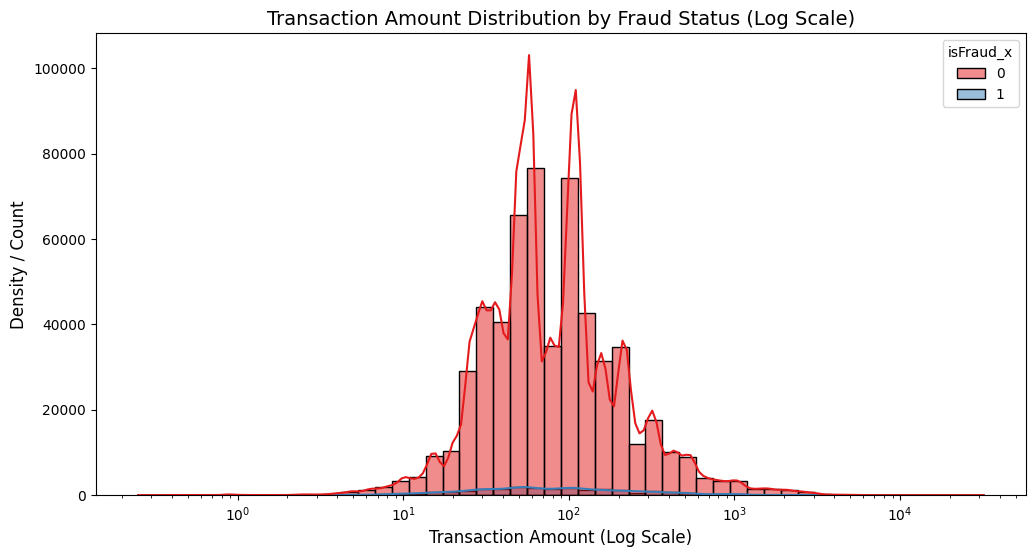

In [15]:
plt.figure(figsize=(12, 6))

# Using log10 to handle extreme right skewness
sns.histplot(data=df, x='TransactionAmt_x', hue='isFraud_x', kde=True, bins=50, palette='Set1', log_scale=True)

plt.title('Transaction Amount Distribution by Fraud Status (Log Scale)', fontsize=14)
plt.xlabel('Transaction Amount (Log Scale)', fontsize=12)
plt.ylabel('Density / Count', fontsize=12)
plt.show()

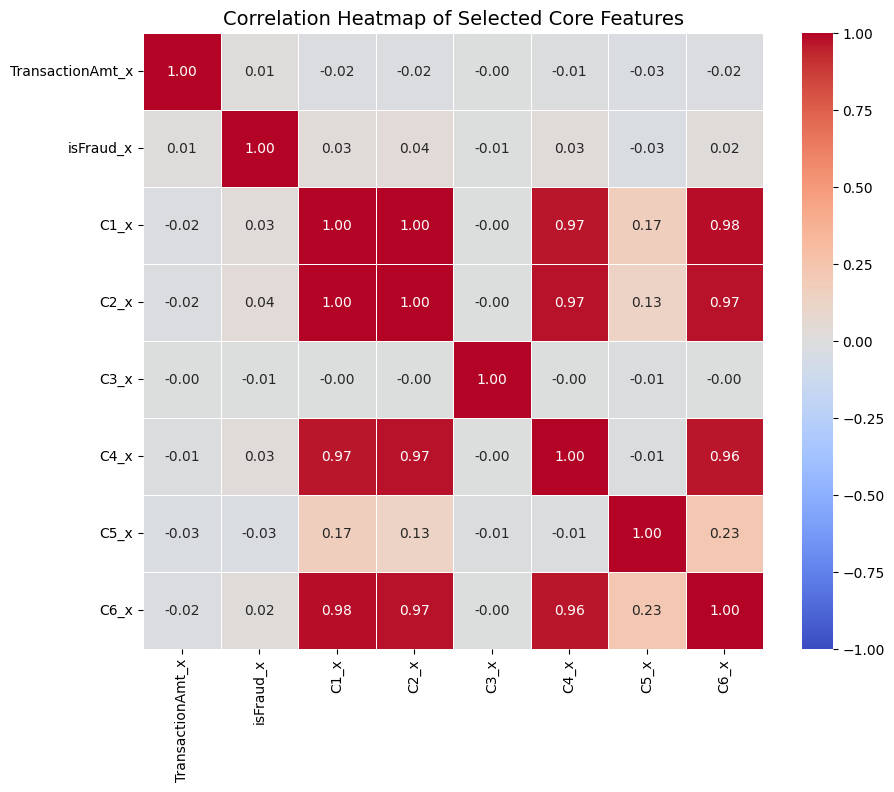

In [16]:
# Selecting a core subset of numerical columns for a clean correlation matrix
c_cols = [c for c in df.columns if c.startswith('C')]
core_features = ['TransactionAmt_x', 'isFraud_x'] + c_cols[:6] # Using first 6 'C' columns as a sample

corr_matrix = df[core_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Selected Core Features', fontsize=14)
plt.show()

/var/folders/2w/c8v4yt5j21s3nkv8j9x_fc340000gn/T/ipykernel_59695/2618375646.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='isFraud_x', y=col, ax=axes[i], palette='muted')
/var/folders/2w/c8v4yt5j21s3nkv8j9x_fc340000gn/T/ipykernel_59695/2618375646.py:17: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axes[i].set_ylim(y_min, y_max)
/var/folders/2w/c8v4yt5j21s3nkv8j9x_fc340000gn/T/ipykernel_59695/2618375646.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='isFraud_x', y=col, ax=axes[i], palette='muted')
/var/folders/2w/c8v4yt5j21s3nkv8j9x_fc340000gn/T/ipykernel_59695/2618375646.py:9: FutureWa

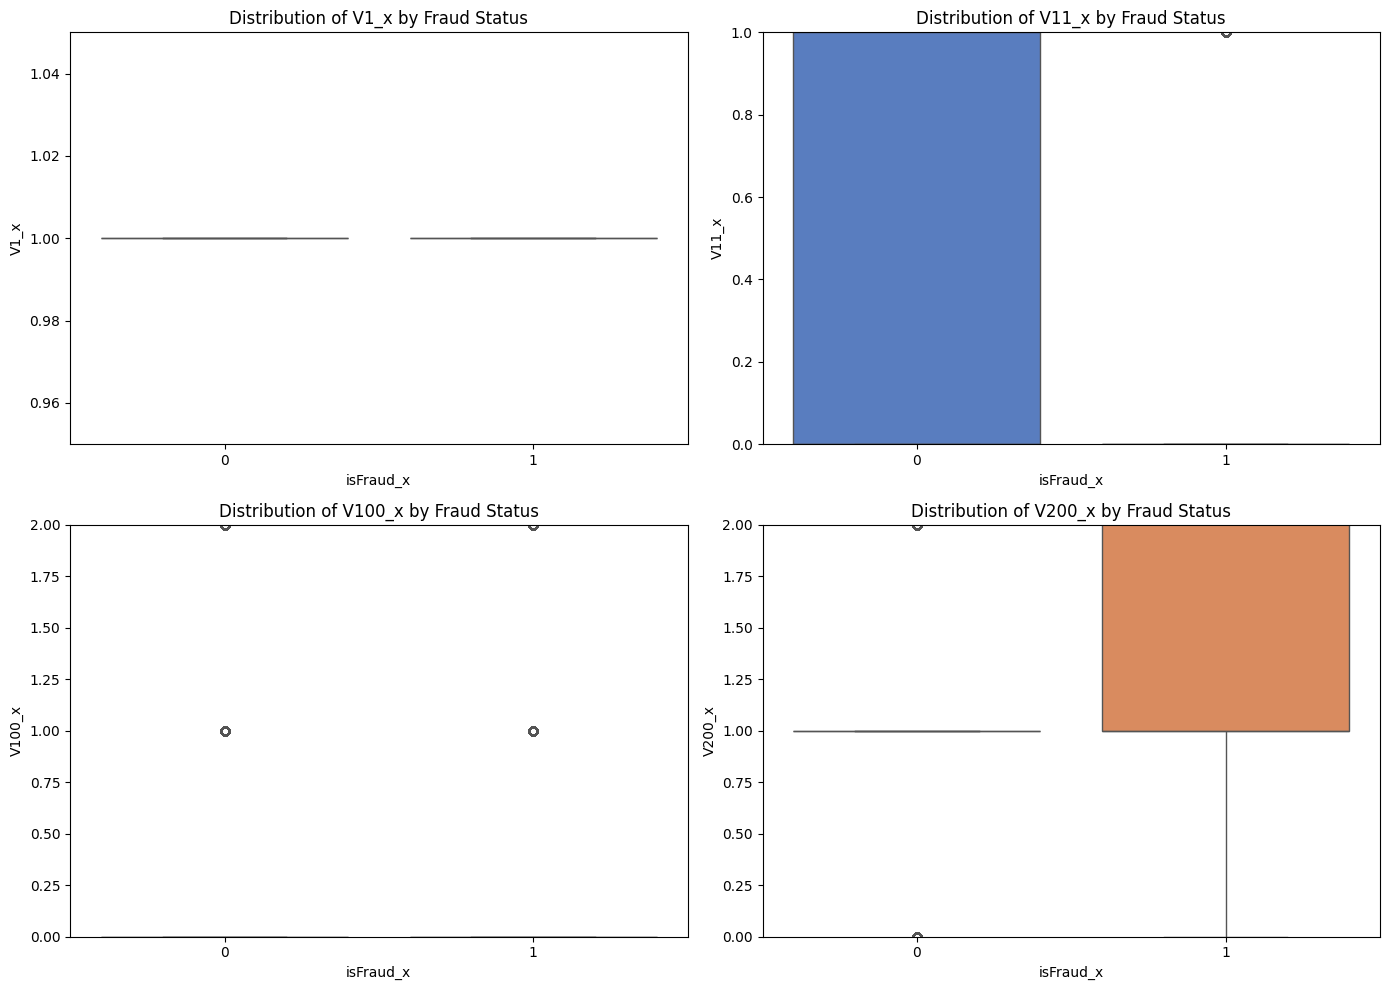

In [20]:
# Sample a few V columns (e.g., V1, V11, V100, V200)
v_cols_sample = ['V1_x', 'V11_x', 'V100_x', 'V200_x']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(v_cols_sample):
    if col in df.columns:
        sns.boxplot(data=df, x='isFraud_x', y=col, ax=axes[i], palette='muted')
        axes[i].set_title(f'Distribution of {col} by Fraud Status')
        axes[i].set_xlabel('isFraud_x')
        axes[i].set_ylabel(col)
        
        # Scaling y-axis if outliers mask the distribution box
        y_max = df[col].quantile(0.95)
        y_min = df[col].quantile(0.05)
        axes[i].set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

/var/folders/2w/c8v4yt5j21s3nkv8j9x_fc340000gn/T/ipykernel_59695/3964391652.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Transaction_Hour'] = (df['TransactionDT_x'] // 3600) % 24
/var/folders/2w/c8v4yt5j21s3nkv8j9x_fc340000gn/T/ipykernel_59695/3964391652.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Transaction_Day'] = (df['TransactionDT_x'] // 86400) % 7


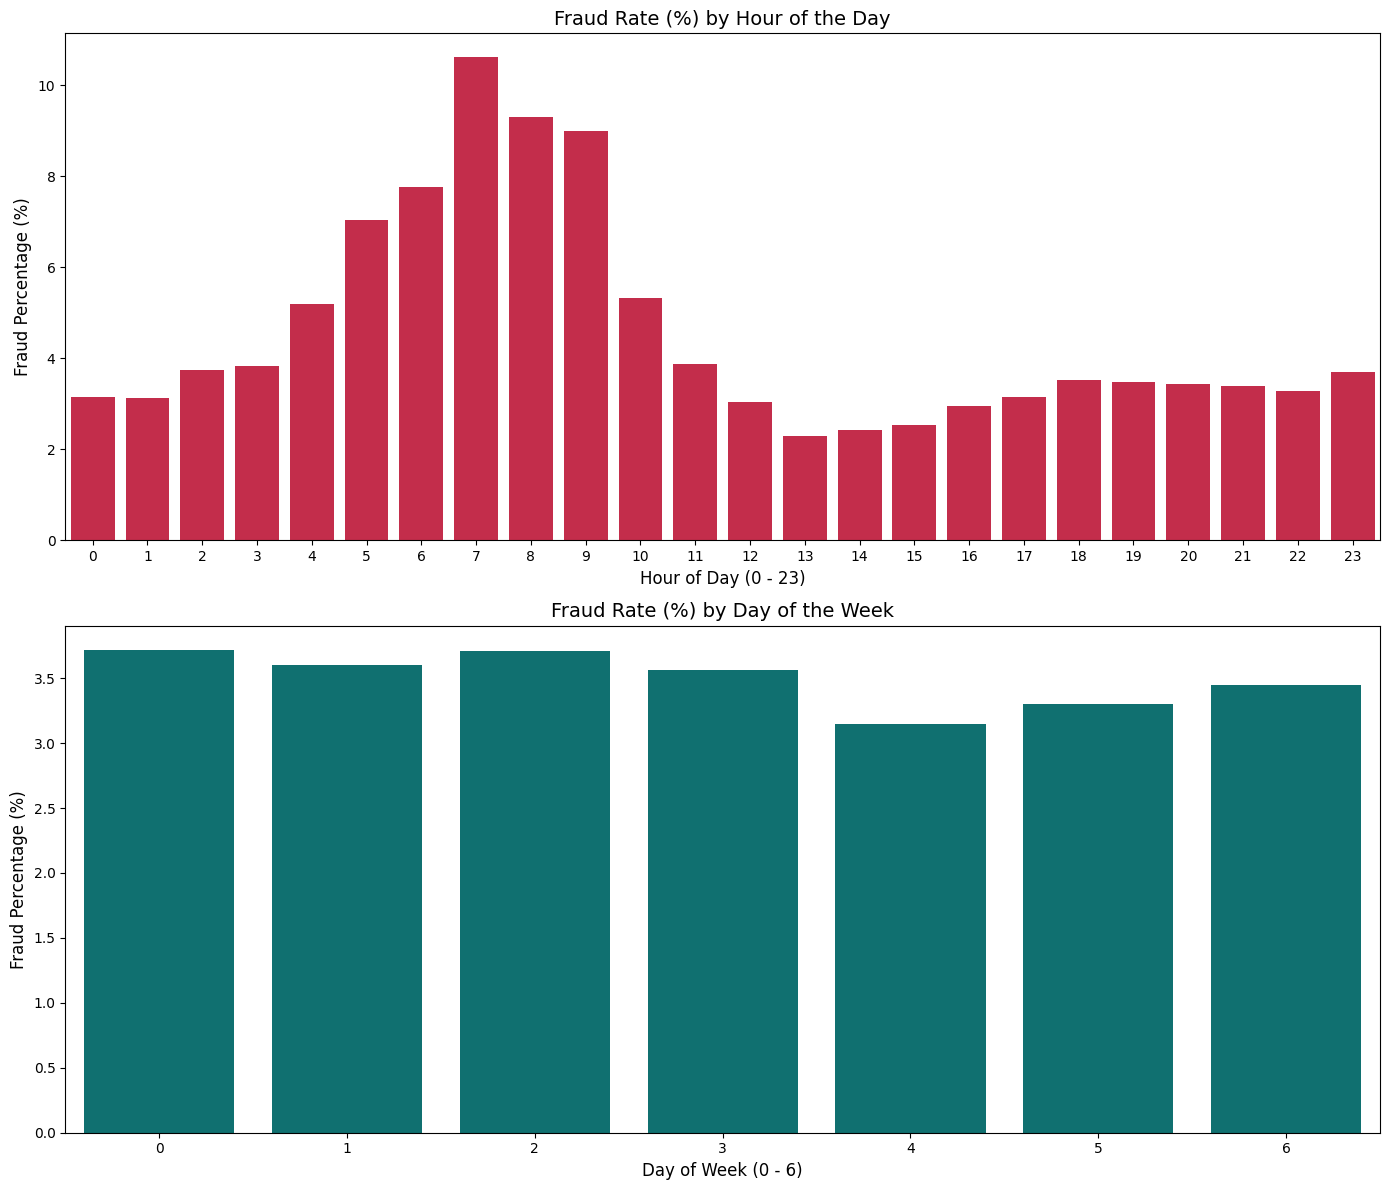

In [21]:
# Engineering temporal features from TransactionDT (seconds)
# 86400 seconds in a day, 3600 seconds in an hour
df['Transaction_Hour'] = (df['TransactionDT_x'] // 3600) % 24
df['Transaction_Day'] = (df['TransactionDT_x'] // 86400) % 7

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# 1. Fraud Frequency / Rate by Hour
hour_fraud_rate = df.groupby('Transaction_Hour')['isFraud_x'].mean() * 100
sns.barplot(x=hour_fraud_rate.index, y=hour_fraud_rate.values, ax=axes[0], color='crimson')
axes[0].set_title('Fraud Rate (%) by Hour of the Day', fontsize=14)
axes[0].set_xlabel('Hour of Day (0 - 23)', fontsize=12)
axes[0].set_ylabel('Fraud Percentage (%)', fontsize=12)

# 2. Fraud Frequency / Rate by Day of Week
day_fraud_rate = df.groupby('Transaction_Day')['isFraud_x'].mean() * 100
sns.barplot(x=day_fraud_rate.index, y=day_fraud_rate.values, ax=axes[1], color='teal')
axes[1].set_title('Fraud Rate (%) by Day of the Week', fontsize=14)
axes[1].set_xlabel('Day of Week (0 - 6)', fontsize=12)
axes[1].set_ylabel('Fraud Percentage (%)', fontsize=12)

plt.tight_layout()
plt.show()